# Flumy Data Generation Pipeline Demo

This notebook demonstrates an end-to-end workflow:
1. Generate a 3D facies model with Flumy
2. Visualize the 3D facies model (static)
3. Extract and visualize slices
4. Convert facies to Acoustic Impedance (AI)
5. Compute reflectivity and visualize it (slice + 3D view)
6. Generate and visualize RMS attributes

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Optional for static 3D plotting
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Ensure project root is importable when notebook is opened from notebooks/
repo_root = Path.cwd().resolve()
if not (repo_root / "diffsim").exists():
    candidate = repo_root.parent
    if (candidate / "diffsim").exists():
        os.chdir(candidate)
        repo_root = candidate

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from diffsim.data.flumy_generator import FlumyGenerator
from diffsim.data.seismic import (
    DEFAULT_AI,
    compute_reflectivity_vertical,
    facies_to_ai,
    generate_rms_from_facies_3d,
)

print(f"Repository root: {repo_root}")
print("Imports complete.")

/home/tharitt/working/DiffSim/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository root: /home/tharitt/working/DiffSim
Imports complete.


In [2]:
# Reproducible random behavior for noise and plot sampling
rng = np.random.default_rng(42)

# Keep a moderate grid size for a fast, interactive notebook experience
gen = FlumyGenerator(
    nx=40,
    ny=40,
    mesh=10,
    hmax=2.0,
    ng=45,
    isbx=80,
    zul=3.0,
    dz=0.15,
    verbose=False,
)

facies_block = gen.generate(seed=7)
print("Generated facies block")
print("Shape (nx, ny, nz):", facies_block.shape)
print("Dtype:", facies_block.dtype)
print("Unique facies codes:", np.unique(facies_block))

#  WARNING  # : Some parameters are out of the usual range of values:
- The domain width (400m) is too narrow for the given channel width (20m). Meander loops will not be fully displayed on the domain
- The domain length (400m) is too short for the given channel width (20m). Meander loops will not be fully displayed on the domain
Generated facies block
Shape (nx, ny, nz): (40, 40, 20)
Dtype: int8
Unique facies codes: [0 1 2]


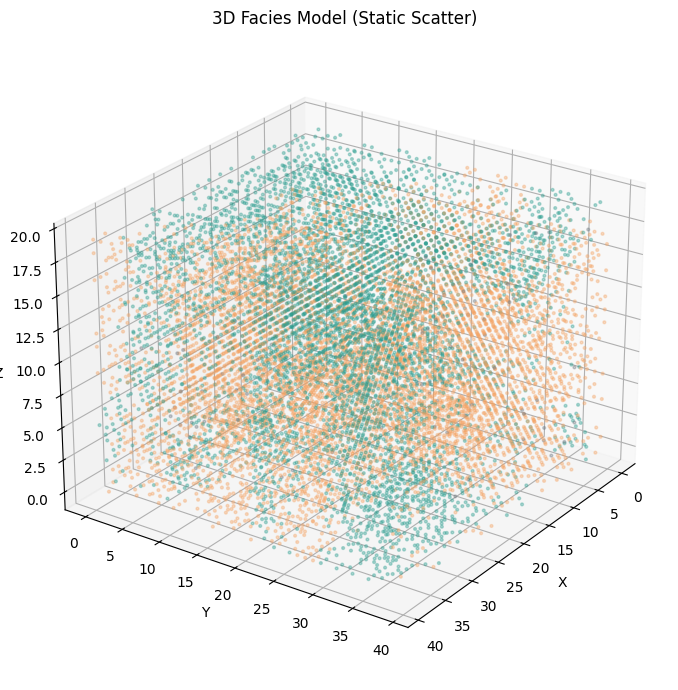

In [3]:
# 3D facies visualization as a static point cloud
# 0=mud, 1=bank, 2=sand
coords = np.argwhere(np.ones_like(facies_block, dtype=bool))
vals = facies_block[coords[:, 0], coords[:, 1], coords[:, 2]]

# Downsample points so the plot remains responsive
max_points = 12000
if coords.shape[0] > max_points:
    pick = rng.choice(coords.shape[0], size=max_points, replace=False)
    coords = coords[pick]
    vals = vals[pick]

facies_colors = np.array(["#6c757d", "#f4a261", "#2a9d8f"])
point_colors = facies_colors[vals]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=point_colors, s=4, alpha=0.35)
ax.set_title("3D Facies Model (Static Scatter)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.view_init(elev=25, azim=35)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3626127/1143747590.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


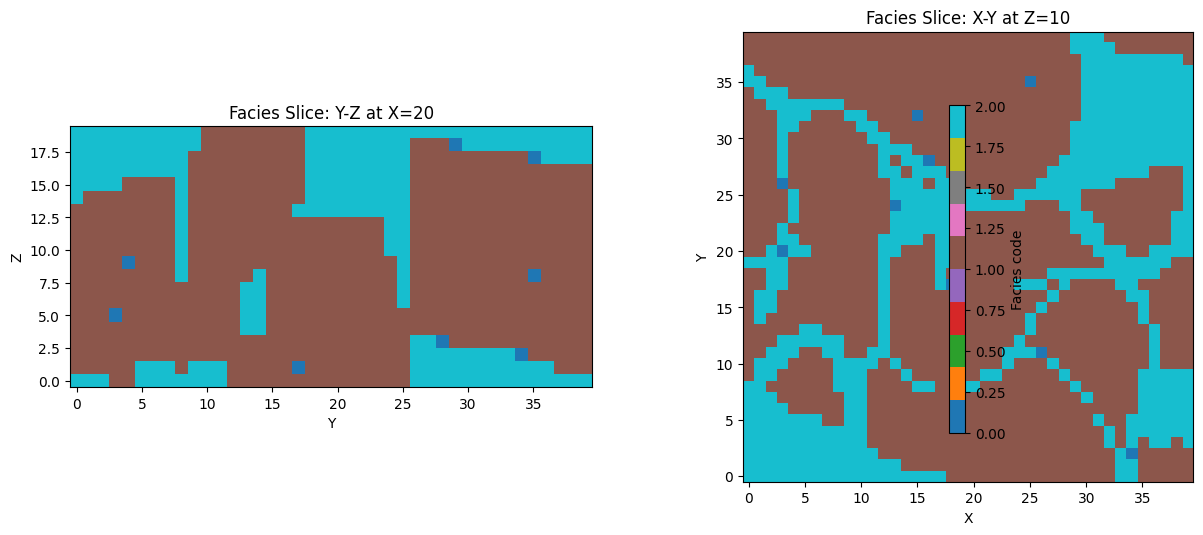

In [4]:
# Slice visualization in two orthogonal planes
nx, ny, nz = facies_block.shape
x_mid = nx // 2
z_mid = nz // 2

slice_x = facies_block[x_mid, :, :]
slice_z = facies_block[:, :, z_mid]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(slice_x.T, origin="lower", cmap="tab10", vmin=0, vmax=2)
axes[0].set_title(f"Facies Slice: Y-Z at X={x_mid}")
axes[0].set_xlabel("Y")
axes[0].set_ylabel("Z")

im1 = axes[1].imshow(slice_z.T, origin="lower", cmap="tab10", vmin=0, vmax=2)
axes[1].set_title(f"Facies Slice: X-Y at Z={z_mid}")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("Facies code")
plt.tight_layout()
plt.show()

In [5]:
# Convert facies to AI and compute reflectivity volume
ai_block = facies_to_ai(facies_block, ai_values=DEFAULT_AI)
refl_block = compute_reflectivity_vertical(ai_block)

print("AI block shape:", ai_block.shape)
print("AI range:", float(ai_block.min()), float(ai_block.max()))
print("Reflectivity shape:", refl_block.shape)
print("Reflectivity range:", float(refl_block.min()), float(refl_block.max()))

AI block shape: (40, 40, 20)
AI range: 7000.0 10000.0
Reflectivity shape: (40, 40, 19)
Reflectivity range: -0.1764705926179886 0.1764705926179886


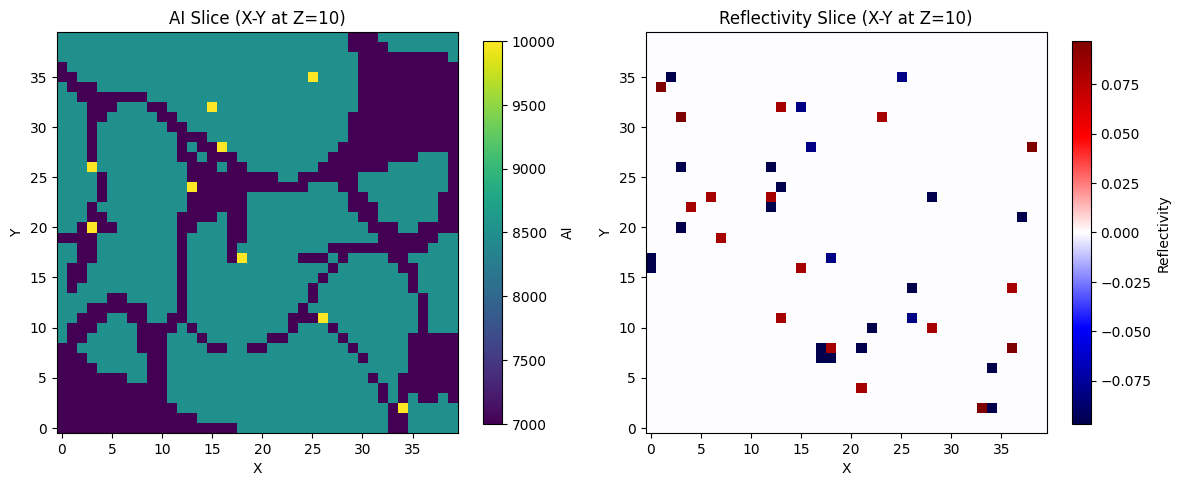

In [6]:
# Slice view for AI and reflectivity
z_ai = z_mid
z_refl = min(z_ai, refl_block.shape[2] - 1)

ai_slice = ai_block[:, :, z_ai]
refl_slice = refl_block[:, :, z_refl]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(ai_slice.T, origin="lower", cmap="viridis")
axes[0].set_title(f"AI Slice (X-Y at Z={z_ai})")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
fig.colorbar(im0, ax=axes[0], shrink=0.85, label="AI")

vabs = np.percentile(np.abs(refl_slice), 99)
im1 = axes[1].imshow(refl_slice.T, origin="lower", cmap="seismic", vmin=-vabs, vmax=vabs)
axes[1].set_title(f"Reflectivity Slice (X-Y at Z={z_refl})")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
fig.colorbar(im1, ax=axes[1], shrink=0.85, label="Reflectivity")

plt.tight_layout()
plt.show()

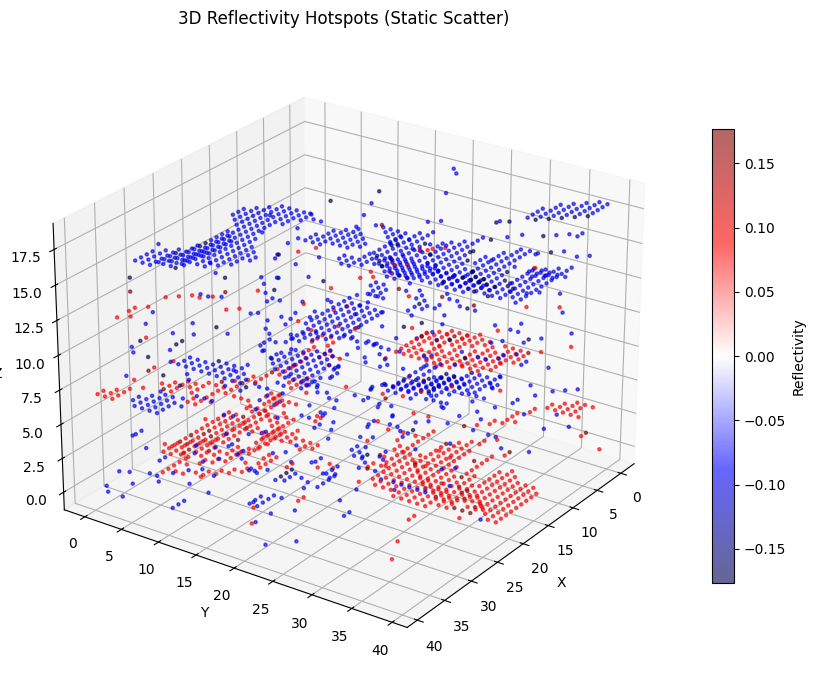

In [7]:
# 3D static view of high-magnitude reflectivity points
threshold = np.percentile(np.abs(refl_block), 97)
rcoords = np.argwhere(np.abs(refl_block) >= threshold)
rvals = refl_block[rcoords[:, 0], rcoords[:, 1], rcoords[:, 2]]

# Additional downsample for plotting speed
max_r_points = 10000
if rcoords.shape[0] > max_r_points:
    pick = rng.choice(rcoords.shape[0], size=max_r_points, replace=False)
    rcoords = rcoords[pick]
    rvals = rvals[pick]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    rcoords[:, 0],
    rcoords[:, 1],
    rcoords[:, 2],
    c=rvals,
    cmap="seismic",
    s=5,
    alpha=0.6,
)
ax.set_title("3D Reflectivity Hotspots (Static Scatter)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.view_init(elev=25, azim=35)
cb = fig.colorbar(sc, ax=ax, shrink=0.7)
cb.set_label("Reflectivity")
plt.tight_layout()
plt.show()

RMS shape: (40, 40)
RMS range: -1.0 1.0


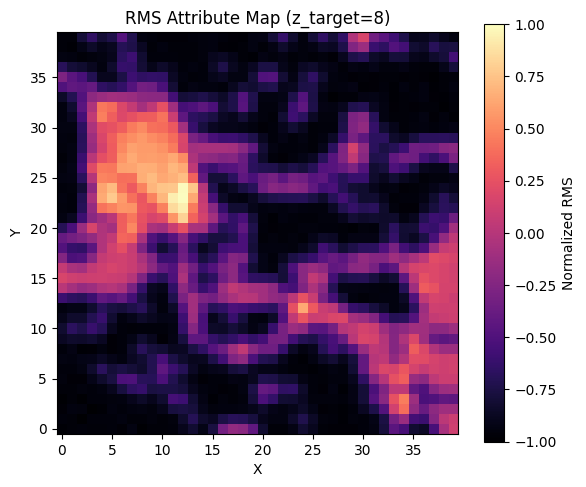

In [8]:
# Generate RMS map at a target depth and visualize
z_target = min(8, nz - 2)
rms_map = generate_rms_from_facies_3d(
    facies_block,
    z_target=z_target,
    ai_values=DEFAULT_AI,
    f_dominant=25.0,
    rms_window_half=3,
    noise_level=0.03,
    smooth_sigma=0.8,
    rng=rng,
)

print("RMS shape:", rms_map.shape)
print("RMS range:", float(rms_map.min()), float(rms_map.max()))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rms_map.T, origin="lower", cmap="magma", vmin=-1.0, vmax=1.0)
ax.set_title(f"RMS Attribute Map (z_target={z_target})")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.colorbar(im, ax=ax, label="Normalized RMS")
plt.tight_layout()
plt.show()

## Notes

- Facies encoding uses 0=mud, 1=bank, 2=sand.
- AI is derived from facies using default rock-property mapping.
- Reflectivity is vertical and has one fewer sample along Z.
- RMS is normalized to the range [-1, 1] in the seismic utility pipeline.